**BACKGROUND REMOVAL EXPERIMENTS**

In [6]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import re
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from config import io_config


ENSEMBLE ALGORITHM

🧭 Processing images:   0%|          | 0/30 [00:00<?, ?it/s]

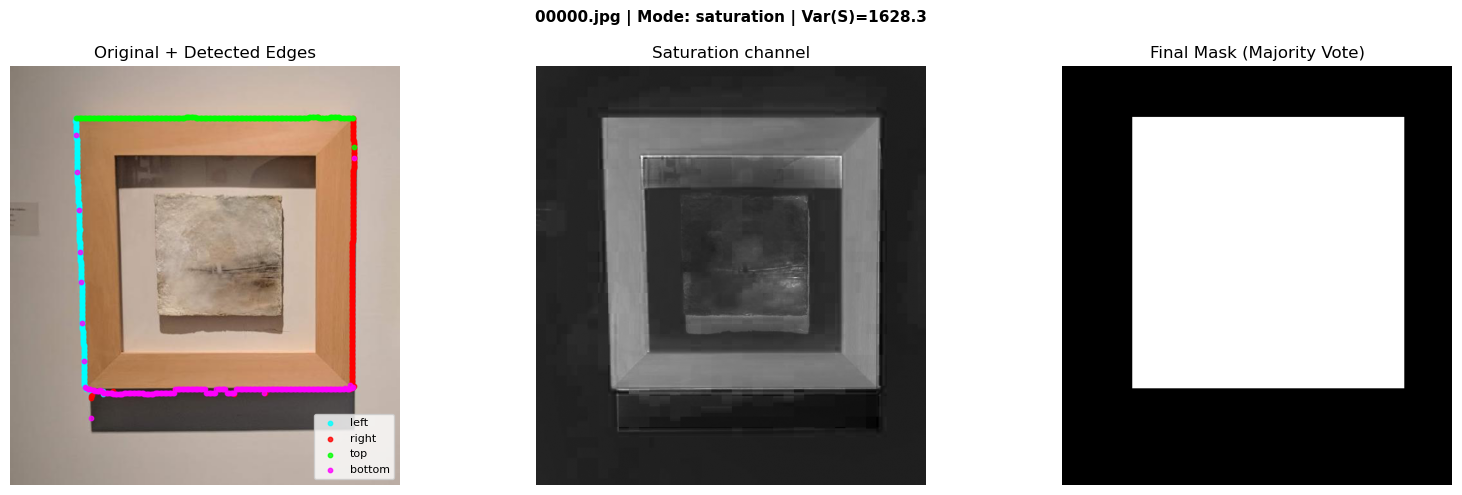

🧭 Processing images:   3%|▎         | 1/30 [00:17<08:14, 17.05s/it]

✅ Saved mask: 00000.png


🧭 Processing images:   3%|▎         | 1/30 [00:21<10:13, 21.16s/it]


KeyboardInterrupt: 

In [ ]:
# FRAME EDGE DETECTION PIPELINE

import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm
from pathlib import Path


# CONFIGURATION

SCAN_STEP = 2
EDGE_BOOTSTRAPS = [10]
RUN_WINDOWS = [2]
DELTA_INTS = [35, 40, 45, 50, 55, 60, 65, 70]
CONSISTENCIES = [2]
TOLS = [15]
VAR_THRESHOLD = 480.0  # If var(S) < threshold → use luminance instead of saturation

MASK_DIR = Path("predicted_masks")
MASK_DIR.mkdir(exist_ok=True)


# BASE FUNCTIONS
def first_transition_idx(line, side="left", edge_bootstrap=10, run_window=7,
                         delta_int=20.0, consistency=7):
    """
    Detects the first consistent intensity transition along a 1D profile.
    """
    n = len(line)

    if side in ("left", "top"):
        base = np.mean(line[:edge_bootstrap])
        step_range = range(edge_bootstrap, n - run_window - consistency)
        direction = +1
    else:
        base = np.mean(line[-edge_bootstrap:])
        step_range = range(n - edge_bootstrap - run_window - consistency, edge_bootstrap, -1)
        direction = -1

    def win_mean(i): return np.mean(line[i:i + run_window])

    for i in step_range:
        seq = [win_mean(i + j * direction) for j in range(consistency)]
        if all(abs(m - base) > delta_int for m in seq):
            return i
    return None


def detect_edge_points(gray, direction="left", step=2, **params):
    """
    Scans image lines (horizontal/vertical) and collects edge points.
    """
    H, W = gray.shape
    pts = []

    if direction in ("left", "right"):
        for y in range(0, H, step):
            idx = first_transition_idx(gray[y, :], side=direction, **params)
            if idx is not None:
                pts.append((idx, y))
    else:
        for x in range(0, W, step):
            idx = first_transition_idx(gray[:, x], side=direction, **params)
            if idx is not None:
                pts.append((x, idx))

    return np.array(pts, dtype=float)


def filter_outliers(points, axis=0, tol=20):
    """
    Filters points beyond ±tol from median along chosen axis.
    """
    if points.size == 0:
        return points
    med = np.median(points[:, axis])
    return points[np.abs(points[:, axis] - med) < tol]


def get_adaptive_channel(img_rgb):
    """
    Chooses the most informative channel:
      - Saturation (S) by default
      - Luminance (Y) if S variance is too low
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    ycbcr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

    s = hsv[:, :, 1].astype(np.float32)
    Y = ycbcr[:, :, 0].astype(np.float32)

    var_s = np.var(s)
    if var_s < VAR_THRESHOLD:
        return Y.astype(np.uint8), "luminance", var_s
    else:
        return s.astype(np.uint8), "saturation", var_s


# IMAGE PROCESSING PIPELINE

def process_image(img_rgb, param_grid):
    """
    Performs edge detection and builds the final mask
    through majority voting.
    """
    gray, mode, var_s = get_adaptive_channel(img_rgb)
    H, W = gray.shape
    accum_mask = np.zeros((H, W), np.uint16)
    collected_edges = None

    for (edge_bootstrap, run_window, delta_int, consistency, tol) in param_grid:
        edges_raw = {
            "left": detect_edge_points(gray, "left", step=SCAN_STEP,
                                       edge_bootstrap=edge_bootstrap, run_window=run_window,
                                       delta_int=delta_int, consistency=consistency),
            "right": detect_edge_points(gray, "right", step=SCAN_STEP,
                                        edge_bootstrap=edge_bootstrap, run_window=run_window,
                                        delta_int=delta_int, consistency=consistency),
            "top": detect_edge_points(gray, "top", step=SCAN_STEP,
                                      edge_bootstrap=edge_bootstrap, run_window=run_window,
                                      delta_int=delta_int, consistency=consistency),
            "bottom": detect_edge_points(gray, "bottom", step=SCAN_STEP,
                                         edge_bootstrap=edge_bootstrap, run_window=run_window,
                                         delta_int=delta_int, consistency=consistency),
        }

        if collected_edges is None:
            collected_edges = edges_raw

        edges = {
            k: filter_outliers(v, axis=(0 if k in ["left", "right"] else 1), tol=tol)
            for k, v in edges_raw.items()
        }

        left_x = int(np.median(edges["left"][:, 0])) if edges["left"].size else 0
        right_x = int(np.median(edges["right"][:, 0])) if edges["right"].size else W - 1
        top_y = int(np.median(edges["top"][:, 1])) if edges["top"].size else 0
        bottom_y = int(np.median(edges["bottom"][:, 1])) if edges["bottom"].size else H - 1

        right_x, bottom_y = max(right_x, left_x + 1), max(bottom_y, top_y + 1)

        mask = np.zeros((H, W), np.uint8)
        mask[top_y:bottom_y, left_x:right_x] = 1
        accum_mask += mask

    threshold_votes = int(len(param_grid) * 0.5)
    final_mask = np.where(accum_mask >= threshold_votes, 255, 0).astype(np.uint8)

    return final_mask, gray, mode, var_s, collected_edges


# MAIN LOOP
def run_dataset(dev_dir, max_imgs=30):
    """
    Runs the frame detection pipeline across all .jpg images
    in a given directory and saves binary masks to `predicted_masks/`.
    """
    db_images = sorted([p for p in Path(dev_dir).iterdir() if p.suffix.lower() == ".jpg"])
    n_imgs = min(max_imgs, len(db_images))
    param_grid = list(product(EDGE_BOOTSTRAPS, RUN_WINDOWS, DELTA_INTS, CONSISTENCIES, TOLS))

    for img_path in tqdm(db_images[:n_imgs], desc="Processing images"):
        try:
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            final_mask, gray, mode, var_s, edges = process_image(img_rgb, param_grid)

            # Save mask
            mask_name = MASK_DIR / f"{img_path.stem}.png"
            cv2.imwrite(str(mask_name), final_mask)

            # Visualization
            fig, axs = plt.subplots(1, 3, figsize=(16, 5))
            plt.suptitle(f"{img_path.name} | Mode: {mode} | Var(S)={var_s:.1f}",
                         fontsize=11, fontweight="bold")

            # Original + Detected Edges
            axs[0].imshow(img_rgb)
            axs[0].set_title("Original + Detected Edges")
            axs[0].axis("off")

            if edges:
                color_map = {"left": "cyan", "right": "red", "top": "lime", "bottom": "magenta"}
                for k, c in color_map.items():
                    if edges[k].size:
                        axs[0].scatter(edges[k][:, 0], edges[k][:, 1], s=10, c=c, label=k, alpha=0.8)
                axs[0].legend(loc="lower right", fontsize=8)

            # Channel Used
            axs[1].imshow(gray, cmap="gray")
            axs[1].set_title(f"{mode.capitalize()} channel")
            axs[1].axis("off")

            # Final Mask
            axs[2].imshow(final_mask, cmap="gray")
            axs[2].set_title("Final Mask (Majority Vote)")
            axs[2].axis("off")

            plt.tight_layout()
            plt.show()

            print(f"Saved mask: {mask_name.name}")

        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")


# RUN PIPELINE
run_dataset(io_config.DEV_DIR)
